In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot  as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
 

In [3]:
data = pd.read_csv('Salary_Data (1).csv')

In [6]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [7]:
x=data.iloc[:, :-1].values
y=data.iloc[:, 1].values
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=10)

In [41]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=10)
x_poly_train = poly.fit_transform(x_train)
x_poly_test = poly.transform(x_test)

In [42]:
x_poly_test

array([[1.00000000e+00, 6.80000000e+00, 4.62400000e+01, 3.14432000e+02,
        2.13813760e+03, 1.45393357e+04, 9.88674826e+04, 6.72298882e+05,
        4.57163240e+06, 3.10871003e+07, 2.11392282e+08],
       [1.00000000e+00, 3.20000000e+00, 1.02400000e+01, 3.27680000e+01,
        1.04857600e+02, 3.35544320e+02, 1.07374182e+03, 3.43597384e+03,
        1.09951163e+04, 3.51843721e+04, 1.12589991e+05],
       [1.00000000e+00, 2.90000000e+00, 8.41000000e+00, 2.43890000e+01,
        7.07281000e+01, 2.05111490e+02, 5.94823321e+02, 1.72498763e+03,
        5.00246413e+03, 1.45071460e+04, 4.20707233e+04],
       [1.00000000e+00, 1.50000000e+00, 2.25000000e+00, 3.37500000e+00,
        5.06250000e+00, 7.59375000e+00, 1.13906250e+01, 1.70859375e+01,
        2.56289062e+01, 3.84433594e+01, 5.76650391e+01],
       [1.00000000e+00, 2.00000000e+00, 4.00000000e+00, 8.00000000e+00,
        1.60000000e+01, 3.20000000e+01, 6.40000000e+01, 1.28000000e+02,
        2.56000000e+02, 5.12000000e+02, 1.02400000e+

In [56]:
poly_model = LinearRegression()
poly_model.fit(x_poly_train, y_train)
y_poly_pred_train = poly_model.predict(x_poly_train)


In [44]:
y_poly_pred

array([ 59317.05643313, 109327.67817433,  59072.47186579,  57703.7927197 ,
        74076.49958332,  60667.29522936,  72668.16273054,  57891.33618894,
        59072.47186579, 112246.47564198, 115080.58598398, 116109.02773511,
       108381.12288315,  58858.74764911, 110182.25327241, 128010.47784391,
        57999.59712139, 114323.25752649,  64179.99869012,  65854.04915881,
        57703.50093225,  62774.40080129,  57723.47333599,  58512.26663311])

In [57]:
poly_model = LinearRegression()
poly_model.fit(x_poly_train, y_train)
y_poly_pred_test = poly_model.predict(x_poly_test)
y_poly_pred


array([87826.08623643, 57999.59712139, 57851.13342946, 57704.57145175,
       57713.37024732, 93732.34415956])

In [46]:
x_range = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_range_pred = poly_model.predict(x_range_poly)

In [47]:
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9356.86]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.609e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[13.76]


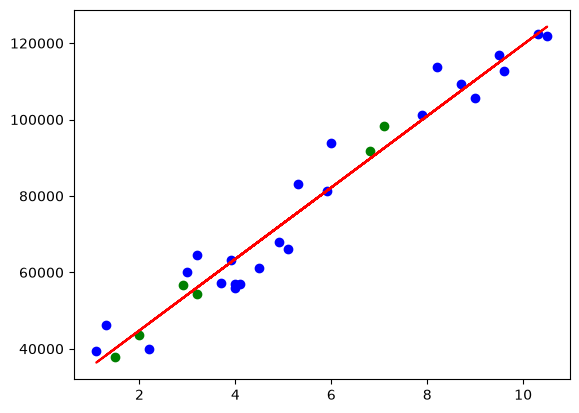

In [48]:
plt.scatter(x_train, y_train, color='blue', label='Data Points')
plt.scatter(x_test, y_test, color='green', label='Test Points')
plt.plot(x_train, lin_reg.predict(x_train), color='red', label='Linear Regression')

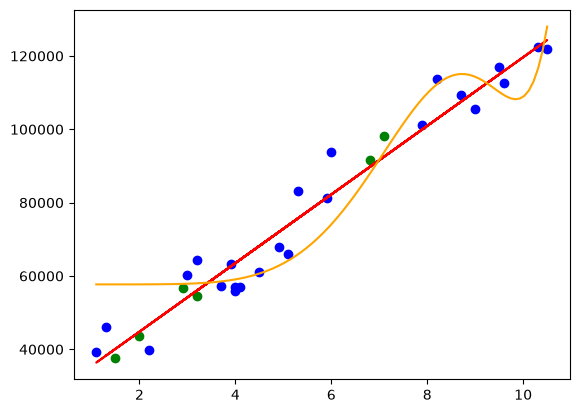

In [49]:
plt.scatter(x_train, y_train, color='blue', label='Data Points')
plt.scatter(x_test, y_test, color='green', label='Test Points')
plt.plot(x_train, lin_reg.predict(x_train), color='red', label='Linear Regression')
plt.plot(x_range, y_range_pred, color='orange', label='Polynomial Regression (Degree 15)')

In [52]:
y_lin_pred = lin_reg.predict(x_train)
y_lin_pred_test = lin_reg.predict(x_test)
train_lin_r2 = r2_score(y_train, y_lin_pred)
test_lin_r2 = r2_score(y_test, y_lin_pred_test)
print(f"Linear Regression R^2 Score (Train): {train_lin_r2:.4f}")
print(f"Linear Regression R^2 Score (Test): {test_lin_r2:.4f}")    

Linear Regression R^2 Score (Train): 0.9495
Linear Regression R^2 Score (Test): 0.9816


In [58]:
# y_lin_pred = poly_model.predict(x_train)
# y_lin_pred_test = poly_model.predict(x_test)
train_lin_r2 = r2_score(y_train, y_poly_pred_train)
test_lin_r2 = r2_score(y_test, y_poly_pred_test)
print(f"Linear Regression R^2 Score (Train): {train_lin_r2:.4f}")
print(f"Linear Regression R^2 Score (Test): {test_lin_r2:.4f}")    

Linear Regression R^2 Score (Train): 0.8874
Linear Regression R^2 Score (Test): 0.7967


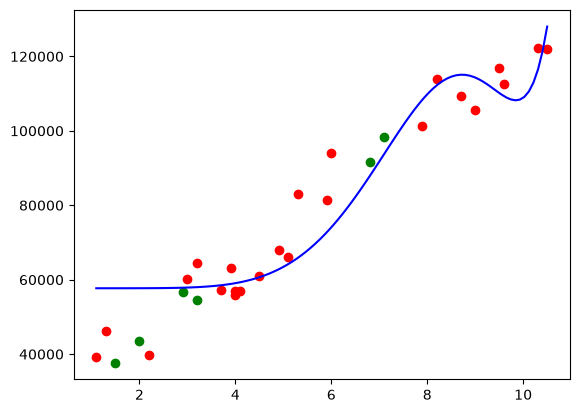

In [60]:
# plt.scatter(x_poly_pred_train, y_poly_pred_tes, color='blue', label='Polynomial Regression Predictions (Train)')
plt.scatter(x_train, y_train, color ="red")
plt.scatter(x_test, y_test, color = "green", label="Test Data")
plt.plot(x_range, y_range_pred, color ="blue",label = "poly Regression")

In [61]:
y_lin_pred_train = lin_reg.predict(x_train)
y_lin_pred_test = lin_reg.predict(x_test)
train_lin_r2 = r2_score(y_train, y_lin_pred_train)
test_lin_r2 = r2_score(y_test, y_lin_pred_test)
print(train_lin_r2)
print(test_lin_r2)

0.9494673013344644
0.9816423482070253


In [62]:
# y_poly_pred_train = poly_model.predict(x_train)
# y_poly_pred_test = poly_model.predict(x_test)
train_lin_r2 = r2_score(y_train, y_poly_pred_train)
test_lin_r2 = r2_score(y_test, y_poly_pred_test)
print("r2score _train",train_lin_r2)
print("r2score _test",test_lin_r2)

r2score _train 0.8873576516635407
r2score _test 0.7966827342689082
